# 2.13 AI-Ready Data

This lesson is the capstone of the data pillar. The previous lessons taught you to read, clean, transform, and describe geoscience data. This one defines what it means for a dataset to be **AI-ready**, and demonstrates the two failure modes that ruin otherwise careful projects: preprocessing leakage and wrong splits for autocorrelated data.

[![Lecture Slides](../img/teaching.png)](../slides/MLReadyDatasets.pdf)

## 1. An operational definition of AI-ready data

"AI-ready" is not a feeling. A dataset is AI-ready when it passes this checklist:

1. **Documented provenance, license, and citation.** Where did every byte come from, who owns it, and how must it be cited? If part of the data is synthetic, that is disclosed.
2. **Machine-readable metadata (a data card).** A file that ships with the data and states what the variables are, in what units, how they were collected or generated, and what the known limitations are. A README written for humans is not enough; the card should be parseable (YAML, JSON).
3. **Tidy shapes.** One row per observation, one column per variable for tables; explicit, labeled dimensions for arrays. No merged header rows, no units embedded in strings.
4. **Explicit units.** Every physical variable carries its unit in the metadata, not in a comment someone will lose.
5. **A missing-data policy.** Which values are missing, why, how they are encoded (`NaN`, `pd.NA`, a sentinel), and what the recommended handling is.
6. **Benchmark splits shipped with the data.** Train/validation/test membership is stored as a column or an index file, so every user evaluates on the same held-out data.
7. **Leakage controls.** The split design respects the correlation structure of the data (time, space, event membership), and all preprocessing statistics are computed from the training split only.
8. **A class and event inventory.** How many samples, how many of each class, how many distinct events. Rare-event problems look very different from balanced ones, and users must know before they train.

The rest of this notebook builds a small dataset that passes the checklist, then breaks rules 6 and 7 on purpose so you can see the damage in the metrics.

## 2. Workflow reminders: from raw data to an ML dataset

Before the checklist can be satisfied, the data has to exist in a usable form. A condensed workflow, from the earlier lessons:

1. **Pose the problem in general terms.** Transform $A$ into $B$? Predict $y$ from $X$? Choosing a target variable already poses the problem (regression, classification, detection).
2. **Establish what is realistically possible.** Review the literature, ML and not. If experts reach accuracy $x$, that is your first benchmark.
3. **Compile and organize the data early.** One location, machine-readable structures (NumPy, Xarray, pandas), saved in standard formats (Parquet, netCDF, Zarr, HDF5). Never overwrite the raw data.
4. **Characterize the data.** Histograms, distributions, cross-plots, correlation matrices (lessons 2.4 and 2.7). Save the exploration scripts.
5. **Consider feature extraction and dimensionality reduction.** Statistical, temporal, or spectral features (lesson 2.11); PCA or ICA (lesson 2.12).
6. **Consider augmentation.** Bootstrap, synthetic noise, transformed copies — with disclosed provenance (lessons 2.6 and 2.10).
7. **Make the pipeline reproducible.** A script or an sklearn [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) that goes from raw data to the AI-ready product with no manual steps.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mlgeo_synth

rng = np.random.default_rng(2026)
os.makedirs("data/ai_ready_demo", exist_ok=True)

## 3. Build the dataset: a river-discharge-like series with rare floods

We generate ten years of a daily discharge-like series: a seasonal baseflow cycle plus noise, with rare flood events injected as a Poisson process. Because the generator is ours, we know the ground truth: every sample carries a label (`event`) and an event identifier (`event_id`). This is exactly the kind of synthetic dataset lesson 2.10 called admissible — we use it to develop and benchmark methodology, and we disclose how it was made.

The task we will pose: **nowcast whether today is a flood day from the previous seven days of discharge**. Floods are rare, so this is an imbalanced classification problem — common in the geosciences (floods, earthquakes, landslides, algal blooms).

In [2]:
n_years = 10
n_days = int(365.25 * n_years)
day = np.arange(n_days)

# Seasonal baseflow: winter-peaking annual cycle plus white noise, in m^3/s
baseflow = 25.0 + 12.0 * np.cos(2 * np.pi * (day - 20) / 365.25) + rng.normal(0, 3.0, n_days)

df = mlgeo_synth.inject_rare_events(
    baseflow,
    rate_per_year=4.0,
    duration_days=(3, 15),
    amplitude=(5.0, 60.0),
    shape="spike",
    samples_per_day=1,
    seed=2026,
)
df.index = pd.date_range("2015-01-01", periods=len(df), freq="D")
df.index.name = "date"
df = df.rename(columns={"value": "discharge_m3s"})
df.head()

,discharge_m3s,event,event_id
date,,,
2015-01-01,33.917395,0,-1
2015-01-02,37.086430,0,-1
2015-01-03,30.740328,0,-1
2015-01-04,40.677831,0,-1
2015-01-05,38.463208,0,-1


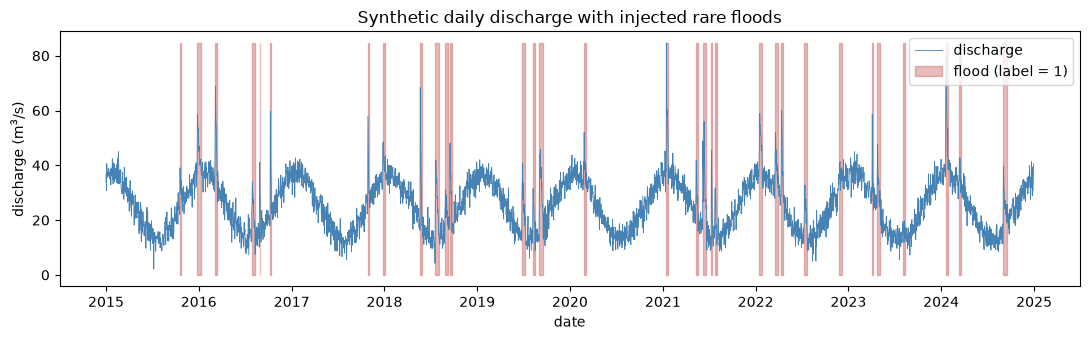

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df.index, df["discharge_m3s"], lw=0.6, color="steelblue", label="discharge")
ax.fill_between(df.index, 0, df["discharge_m3s"].max(), where=df["event"] == 1,
                color="firebrick", alpha=0.3, label="flood (label = 1)")
ax.set_xlabel("date")
ax.set_ylabel("discharge (m$^3$/s)")
ax.legend(loc="upper right")
ax.set_title("Synthetic daily discharge with injected rare floods")
plt.tight_layout()

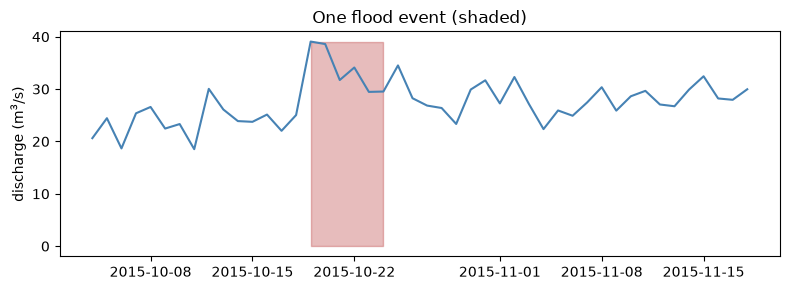

In [4]:
# Zoom on one event to see the shape: sharp rise, exponential recession
one_event = df[df["event_id"] == df.loc[df["event"] == 1, "event_id"].iloc[0]]
window = df.loc[one_event.index[0] - pd.Timedelta(days=15):
                one_event.index[-1] + pd.Timedelta(days=25)]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(window.index, window["discharge_m3s"], color="steelblue")
ax.fill_between(window.index, 0, window["discharge_m3s"].max(),
                where=window["event"] == 1, color="firebrick", alpha=0.3)
ax.set_ylabel("discharge (m$^3$/s)")
ax.set_title("One flood event (shaded)")
plt.tight_layout()

### The class and event inventory

Checklist item 8. Two different numbers matter and they are not interchangeable: the fraction of *samples* that are labeled 1, and the number of *distinct events*. Cross-validation folds are counted in events, not samples: 40 events split five ways leaves only ~8 events per fold, no matter how many flood-days there are.

In [5]:
n_events = df.loc[df["event_id"] >= 0, "event_id"].nunique()
durations = df[df["event_id"] >= 0].groupby("event_id").size()

inventory = pd.Series({
    "total samples (days)": len(df),
    "flood samples": int(df["event"].sum()),
    "flood sample fraction": round(df["event"].mean(), 4),
    "distinct flood events": n_events,
    "median event duration (days)": durations.median(),
    "max event duration (days)": int(durations.max()),
})
inventory

total samples (days)            3652.0000
flood samples                    312.0000
flood sample fraction              0.0854
distinct flood events             33.0000
median event duration (days)       9.0000
max event duration (days)         15.0000
dtype: float64

## 4. The data card

Checklist items 1, 2, 4, 5, and 8, in one machine-readable file. A data card travels with the data — same folder, same repository, versioned together. Below is the card for this dataset, in YAML:

```yaml
name: synthetic_discharge_floods
version: "1.0"
created: "2026-08-11"
description: >
  Ten years of synthetic daily river-discharge-like data with rare injected
  flood events, for teaching rare-event classification and split design.
provenance:
  synthetic: true                      # disclosed, per lesson 2.10
  generator: mlgeo_synth.inject_rare_events
  generator_params: {rate_per_year: 4.0, duration_days: [3, 15],
                     amplitude: [5.0, 60.0], shape: spike, seed: 2026}
  background: "25 + 12*cos(annual cycle) + N(0, 3.0), seed 2026"
license: CC-BY-4.0
citation: "MLGeo course materials, University of Washington, 2026 edition."
sampling:
  cadence: daily
  start: "2015-01-01"
  n_samples: 3652
variables:
  discharge_m3s: {dtype: float64, units: m^3/s, description: daily mean discharge}
  event:         {dtype: int64, units: null, description: "label: 1 = flood day"}
  event_id:      {dtype: int64, units: null, description: "flood id; -1 = background"}
  split:         {dtype: str, values: [train, val, test], description: benchmark split}
missing_data:
  policy: "no missing values by construction; real gauges gap during floods —
           document gaps, do not silently interpolate labels"
class_inventory:
  flood_sample_fraction: ~0.09
  distinct_events: ~40
splits:
  scheme: chronological
  train: "2015-01-01 to 2021-12-31"
  val:   "2022-01-01 to 2022-12-31"
  test:  "2023-01-01 to 2024-12-31"
  rule: "no event spans a split boundary check; preprocessing statistics
         from train only"
known_limitations:
  - synthetic; event shapes are idealized (linear rise, exponential decay)
  - no measurement gaps, rating-curve errors, or sensor drift
```

Nothing here is decoration. Every entry answers a question a future user (including future you) would otherwise have to guess about.

In [6]:
# Ship the splits WITH the data (checklist item 6): a split column, assigned
# chronologically, then write data + card to the same folder.
df["split"] = "train"
df.loc["2022-01-01":"2022-12-31", "split"] = "val"
df.loc["2023-01-01":, "split"] = "test"
print(df["split"].value_counts())
print("\nFlood events per split:")
print(df[df["event_id"] >= 0].groupby("split", observed=True)["event_id"].nunique())

split
train    2557
test      730
val       365
Name: count, dtype: int64

Flood events per split:
split
test      6
train    22
val       5
Name: event_id, dtype: int64


In [7]:
data_card = """\
name: synthetic_discharge_floods
version: "1.0"
created: "2026-08-11"
description: >
  Ten years of synthetic daily river-discharge-like data with rare injected
  flood events, for teaching rare-event classification and split design.
provenance:
  synthetic: true
  generator: mlgeo_synth.inject_rare_events
  generator_params: {rate_per_year: 4.0, duration_days: [3, 15], amplitude: [5.0, 60.0], shape: spike, seed: 2026}
license: CC-BY-4.0
citation: "MLGeo course materials, University of Washington, 2026 edition."
sampling: {cadence: daily, start: "2015-01-01", n_samples: %d}
variables:
  discharge_m3s: {dtype: float64, units: m^3/s}
  event: {dtype: int64, description: "label: 1 = flood day"}
  event_id: {dtype: int64, description: "flood id; -1 = background"}
  split: {dtype: str, values: [train, val, test]}
missing_data: {policy: "no missing values by construction"}
splits: {scheme: chronological, train: "2015-2021", val: "2022", test: "2023-2024"}
""" % len(df)

df.to_csv("data/ai_ready_demo/synthetic_discharge_floods.csv")
with open("data/ai_ready_demo/data_card.yml", "w") as f:
    f.write(data_card)
sorted(os.listdir("data/ai_ready_demo"))

['data_card.yml', 'synthetic_discharge_floods.csv']

In [8]:
# "Machine-readable" means a script can consume it. Read the card back:
import yaml

with open("data/ai_ready_demo/data_card.yml") as f:
    card = yaml.safe_load(f)
print(card["variables"]["discharge_m3s"])
print(card["splits"])

{'dtype': 'float64', 'units': 'm^3/s'}
{'scheme': 'chronological', 'train': '2015-2021', 'val': '2022', 'test': '2023-2024'}


## 5. Features for a flood classifier

We build a deliberately simple feature set: the discharge on each of the previous seven days (lag features, `q_lag1` = yesterday through `q_lag7`), plus the annual cycle encoded as sine and cosine of day-of-year. Today's discharge is *not* a feature — using it would make the task trivial (a flood day *is* a high-discharge day). Nowcasting from the past keeps the problem honest and keeps the label out of the features. The point of this lesson is not the model — it is what the *splits* and the *preprocessing* do to the evaluation.

In [9]:
feat = pd.DataFrame(index=df.index)
for lag in range(1, 8):
    feat[f"q_lag{lag}"] = df["discharge_m3s"].shift(lag)
doy = df.index.dayofyear
feat["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
feat["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
feat["event"] = df["event"]
feat["event_id"] = df["event_id"]
feat["split"] = df["split"]
feat = feat.dropna()

X = feat[[c for c in feat.columns if c.startswith(("q_lag", "doy_"))]]
y = feat["event"]
X.shape, y.mean().round(4)

((3645, 9), np.float64(0.0856))

## 6. Leakage by preprocessing

Checklist item 7, part one. **Every statistic you compute from the data — a mean, a standard deviation, a PCA basis, an imputation value — is part of the model.** If you compute it from the full dataset and then split, information from the test period has already flowed into the features the model trains on. This is leakage by preprocessing.

Here we standardize the features two ways:

- **Wrong:** fit `StandardScaler` on *all* the data, then split and train.
- **Right:** split first, fit the scaler on the *training* data only, and apply it (frozen) to the test data.

The floods in the test years shift the full-data mean and variance, so the wrong version quietly tells the model something about the test period. We score with **average precision** (area under the precision-recall curve), the appropriate metric for a rare positive class — accuracy would be ~97% for a model that never predicts a flood.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler

train_mask = feat["split"] == "train"
test_mask = feat["split"] == "test"
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# WRONG: scaler sees the test data
scaler_leaky = StandardScaler().fit(X)
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(scaler_leaky.transform(X_train), y_train)
ap_leaky = average_precision_score(y_test, clf.predict_proba(scaler_leaky.transform(X_test))[:, 1])

# RIGHT: scaler sees only the training data
scaler_clean = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(scaler_clean.transform(X_train), y_train)
ap_clean = average_precision_score(y_test, clf.predict_proba(scaler_clean.transform(X_test))[:, 1])

print(f"average precision, scaler fit on ALL data (leaky): {ap_leaky:.3f}")
print(f"average precision, scaler fit on TRAIN only:       {ap_clean:.3f}")
print("\nScaler means for q_lag1 differ because the test years contain floods:")
print(f"  full-data mean: {scaler_leaky.mean_[0]:.3f}   train-only mean: {scaler_clean.mean_[0]:.3f}")

average precision, scaler fit on ALL data (leaky): 0.722
average precision, scaler fit on TRAIN only:       0.722

Scaler means for q_lag1 differ because the test years contain floods:
  full-data mean: 26.002   train-only mean: 25.948


On this dataset the two scores are essentially identical: the series is long, roughly stationary, and a scaler carries only two numbers per feature, which a logistic regression can absorb into its weights. Do not take comfort in that. The gap grows when data are short, when the test period drifts away from the training period, or when the preprocessing is richer than a scaler — PCA bases, imputation models, feature selection, and normalization by global percentiles all leak far more than a mean and a standard deviation. The discipline costs nothing: **split first, then fit every preprocessing step on the training split only.** In sklearn, put the scaler and the model in a single `Pipeline` so cross-validation refits the preprocessing inside each fold automatically.

### A leak that wrecks the metric: oversampling before the split

Here is a preprocessing leak with teeth, and one of the most common mistakes with rare events. To fight class imbalance, students often **oversample** the rare class — duplicate flood days until the classes are balanced — and *then* split randomly into train and test. The duplicated copies of the same flood day land on both sides of the split. The model is then tested on exact copies of its training samples.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

Xa, ya = X.to_numpy(), y.to_numpy()

# WRONG: balance the classes first, split second
X_pos_up, y_pos_up = resample(Xa[ya == 1], ya[ya == 1],
                              n_samples=int((ya == 0).sum()), random_state=0)
X_bal = np.vstack([Xa[ya == 0], X_pos_up])
y_bal = np.concatenate([ya[ya == 0], y_pos_up])
X_tr, X_te, y_tr, y_te = train_test_split(X_bal, y_bal, test_size=0.3,
                                          random_state=0, stratify=y_bal)
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(X_tr, y_tr)
ap_wrong = average_precision_score(y_te, rf.predict_proba(X_te)[:, 1])

# RIGHT: split first, oversample the training set only
X_tr, X_te, y_tr, y_te = train_test_split(Xa, ya, test_size=0.3,
                                          random_state=0, stratify=ya)
X_pos_up, y_pos_up = resample(X_tr[y_tr == 1], y_tr[y_tr == 1],
                              n_samples=int((y_tr == 0).sum()), random_state=0)
rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(
    np.vstack([X_tr[y_tr == 0], X_pos_up]),
    np.concatenate([y_tr[y_tr == 0], y_pos_up]))
ap_right = average_precision_score(y_te, rf.predict_proba(X_te)[:, 1])

print(f"average precision, oversample BEFORE split (leaky): {ap_wrong:.3f}")
print(f"average precision, oversample train only:           {ap_right:.3f}")

average precision, oversample BEFORE split (leaky): 1.000
average precision, oversample train only:           0.848


The leaky version reports a perfect or near-perfect score — pure fiction, produced entirely by duplicated samples straddling the split. Any preprocessing that creates, duplicates, selects, or transforms samples using knowledge of the whole dataset must happen *inside* the training split, never before it.

## 7. Splits for autocorrelated data

Checklist item 7, part two, and the biggest source of inflated scores in geoscience ML. Our features are seven-day windows of a smooth series: day $t$ and day $t+1$ have six of seven lag values in common. A **random split** scatters the days of a single flood across train and test. The model then "predicts" a test day by having memorized its near-duplicate neighbors in training. The score is real; the skill is not, and it will not transfer to a flood the model has never seen.

The fix is to split along the correlation structure:

- **`TimeSeriesSplit`** trains on the past and tests on the future — the deployment scenario for forecasting.
- **`GroupKFold`** keeps groups intact: all days of one flood event stay on the same side of the split. We group flood days by `event_id` and background days into monthly blocks.

One more deliberate choice: we switch from logistic regression to a **random forest**. A linear model has almost no capacity to memorize individual samples, so it hides the split problem. A random forest memorizes near-duplicates happily — and that capacity is exactly what a random split rewards. We run the identical pipeline (scaler + classifier, so preprocessing refits inside each fold) under the three cross-validation schemes.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, KFold, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(StandardScaler(),
                     RandomForestClassifier(n_estimators=200, random_state=0,
                                            class_weight="balanced"))

# Groups: one group per flood event; background days grouped by 30-day block
day_index = np.arange(len(feat))
groups = np.where(feat["event_id"] >= 0,
                  feat["event_id"],
                  1000 + day_index // 30)

cv_schemes = {
    "KFold (random, shuffled)": (KFold(n_splits=5, shuffle=True, random_state=0), None),
    "TimeSeriesSplit": (TimeSeriesSplit(n_splits=5), None),
    "GroupKFold (by event)": (GroupKFold(n_splits=5), groups),
}

results = {}
for name, (cv, g) in cv_schemes.items():
    scores = cross_val_score(pipe, X, y, cv=cv, groups=g,
                             scoring="average_precision")
    results[name] = scores
    print(f"{name:28s} AP = {scores.mean():.3f} +/- {scores.std():.3f}")

KFold (random, shuffled)     AP = 0.839 +/- 0.034


TimeSeriesSplit              AP = 0.704 +/- 0.039


GroupKFold (by event)        AP = 0.734 +/- 0.053


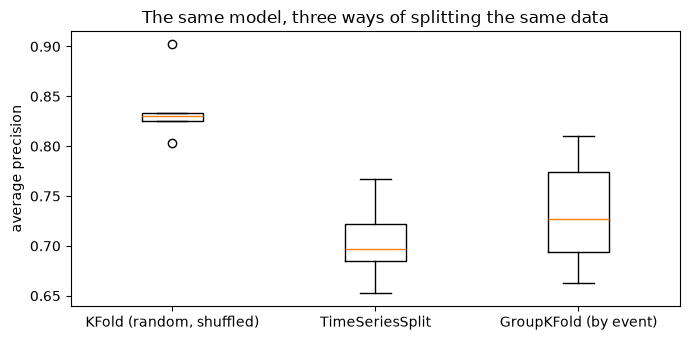

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot([results[k] for k in cv_schemes], tick_labels=list(cv_schemes))
ax.set_ylabel("average precision")
ax.set_title("The same model, three ways of splitting the same data")
plt.tight_layout()

The random `KFold` reports the highest score by a wide margin, and it is the least trustworthy of the three: its test folds are full of samples that are near-copies of training samples, so the forest is graded on floods it has effectively already seen. `TimeSeriesSplit` and `GroupKFold` answer the question you actually care about — *does the model detect floods it has never seen?* — and they answer it less flatteringly. (`TimeSeriesSplit` also scores lowest in part because its early folds train on only a fraction of the data.)

Rules of thumb:

- Time series → split in time (`TimeSeriesSplit`, or a chronological hold-out like our shipped `split` column).
- Event-based data (earthquakes, storms, floods) → split by event (`GroupKFold` on the event identifier). Never let windows from one event straddle the split.
- Spatial data → split by region, not by pixel; nearby pixels are near-duplicates.
- When in doubt, ask: could a sample in the test set be trivially reconstructed from samples in the training set? If yes, the split is wrong.

This is why checklist item 6 says splits ship *with* the data: the dataset builder knows the correlation structure better than any downstream user, and a stored split makes every published score comparable.

## 8. Training, validation, and test sets

### What is the role of a training and a test set

A **training data set** is the foundation of machine learning models. It provides the data used by the algorithm to learn patterns, relationships, and representations necessary for making predictions or decisions. The primary goal of the training data set is to enable the model to minimize the error or loss function by optimizing its parameters.

A **test data set** is used to evaluate the performance of the model on unseen data. Preparing it involves:

1. **Data Splitting**: The test set is a subset of the data, separate from the training set, often 10-30% of the dataset — chosen with the correlation structure in mind, as above.
2. **Hold-Out Principle**: Test data should never overlap with training or validation data, and it should be touched once, at the end. Every time you peek at test scores and change the model in response, the test set degrades into a validation set.
3. **Real-World Representativeness**: The test data should reflect the scenarios where the model will be deployed, ensuring a robust performance evaluation.

### Classic Machine Learning (CML) vs Deep Learning (DL)

1. **CML**: models are simpler, with fewer hyperparameters to tune. A training set is used to fit the model, which is then evaluated on the test set. Cross-validation (as in section 7) assesses performance and reduces overfitting, often removing the need for a separate validation set.

2. **DL**: models are complex, often with millions of parameters, and need a **validation set** in addition to training and test sets. The validation set is used during training to tune hyperparameters (learning rate, number of layers) and to monitor overfitting (early stopping when validation loss stops improving).

A typical split for DL:

- **Training set**: 70-80% of the data.
- **Validation set**: 10-20% of the data.
- **Test set**: 10-20% of the data.

The validation set protects the test set: hyperparameter tuning consumes the validation set, so the test set remains genuinely unseen.

## 9. This checklist is graded

The AI-ready dataset you build for your project milestone will be evaluated against the checklist in section 1: provenance and license, a data card, tidy shapes and units, a missing-data policy, shipped benchmark splits, leakage controls, and a class/event inventory. See the [chapter assignment](2.20_Final_Project_Assignement.md) and the [final project description](../about_this_book/1.10_MLGEO_FinalProject.md).

If you remember one sentence from this pillar: **the split and the preprocessing are part of the dataset, not an afterthought of the model.**